In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Downloading website traffic dataset from Kaggle...")
path = kagglehub.dataset_download("bhanupratapbiswas/website-traffic-analysis")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)
print("Data successfully loaded!")
print(f"Dataset Shape: {df.shape}")
df.head()

100%|██████████| 5.16M/5.16M [00:00<00:00, 155MB/s]

Extracting files...


Data successfully loaded!
Dataset Shape: (226278, 9)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [2]:

print("=== Dataset Columns & Types ===")
print(df.dtypes)
print("\n" + "="*40 + "\n")
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")
df.columns = df.columns.str.strip()
total_sessions = len(df)
print(f"Total Traffic Sessions: {total_sessions:,}")
summary_metrics = {
    "Total Sessions": total_sessions
}
user_cols = [c for c in df.columns if 'user' in c.lower() or 'visitor' in c.lower() or 'client' in c.lower()]
if user_cols:
    unique_users = df[user_cols[0]].nunique()
    summary_metrics["Unique Users"] = unique_users
    print(f"Unique Users / Visitors: {unique_users:,}")
bounce_cols = [c for c in df.columns if 'bounce' in c.lower()]
if bounce_cols:
    avg_bounce = df[bounce_cols[0]].mean()
    summary_metrics["Avg Bounce Rate"] = f"{avg_bounce:.2f}%" if avg_bounce <= 100 else f"{avg_bounce:.2%}"
    print(f"Average Bounce Rate: {summary_metrics['Avg Bounce Rate']}")
duration_cols = [c for c in df.columns if 'duration' in c.lower() or 'time' in c.lower()]
if duration_cols:
    avg_duration = df[duration_cols[0]].mean()
    summary_metrics["Avg Session Duration (sec)"] = f"{avg_duration:.2f} seconds"
    print(f"Average Session Duration: {summary_metrics['Avg Session Duration (sec)']}")

print("\nDataset Summary Stats:")
df.describe(include='all')

=== Dataset Columns & Types ===
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object


=== Missing Values ===
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


Total Traffic Sessions: 226,278

Dataset Summary Stats:


,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


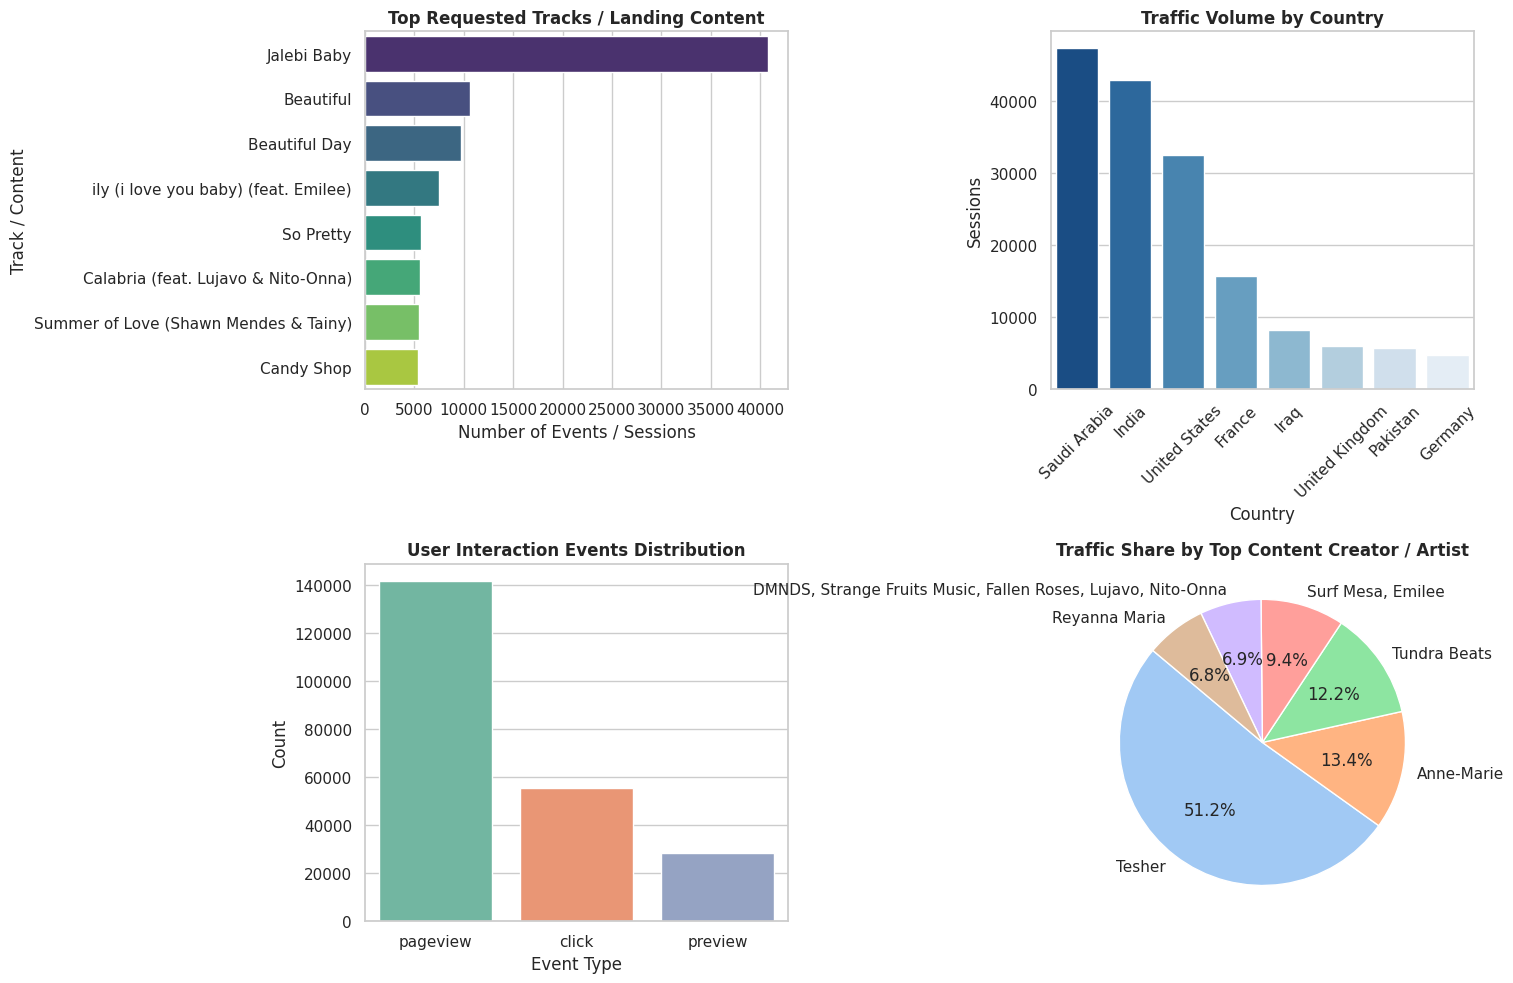

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
top_tracks = df['track'].value_counts().head(8).reset_index()
top_tracks.columns = ['Track / Content', 'Sessions']
sns.barplot(data=top_tracks, y='Track / Content', x='Sessions', ax=axes[0, 0], hue='Track / Content', palette='viridis', legend=False)
axes[0, 0].set_title('Top Requested Tracks / Landing Content', fontweight='bold')
axes[0, 0].set_xlabel('Number of Events / Sessions')
top_countries = df['country'].value_counts().head(8).reset_index()
top_countries.columns = ['Country', 'Sessions']
sns.barplot(data=top_countries, x='Country', y='Sessions', ax=axes[0, 1], hue='Country', palette='Blues_r', legend=False)
axes[0, 1].set_title('Traffic Volume by Country', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
event_counts = df['event'].value_counts().reset_index()
event_counts.columns = ['Event Type', 'Count']
sns.barplot(data=event_counts, x='Event Type', y='Count', ax=axes[1, 0], hue='Event Type', palette='Set2', legend=False)
axes[1, 0].set_title('User Interaction Events Distribution', fontweight='bold')
top_artists = df['artist'].value_counts().head(6)
axes[1, 1].pie(top_artists, labels=top_artists.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Traffic Share by Top Content Creator / Artist', fontweight='bold')

plt.tight_layout()
plt.show()